In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Extracting File from Preprocessed data
import pandas as pd

df = pd.read_csv("../data/processed/telco_processed.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,ContractValue
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,29.850000,1,29.85
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,55.573529,3,1936.30
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,3,107.70
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.905556,3,1903.50
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,1,141.40


In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,ContractValue
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,29.850000,1,29.85
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,55.573529,3,1936.30
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,3,107.70
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.905556,3,1903.50
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,1,141.40


In [4]:
#Classification (Churn prediction)
#So considering churn as separate column
#set random state =42
X = df.drop("Churn", axis=1)
y = df["Churn"]
#Splitting into training and temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)
#Split temporary Data
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [5]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4930, 33)
(1056, 33)
(1057, 33)


In [6]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
import time

# Logistic Regression + Hyperparameter Tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(
        max_iter=5000,
        solver='liblinear'
    ),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Measure training time
start = time.time()

grid.fit(X_train, y_train)

training_time = time.time() - start

print("Best Parameters:", grid.best_params_)
print("Training Time:", training_time)

# Best Model
best_lr = grid.best_estimator_

# Predictions
y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

results = []

results.append([
    "Logistic Regression",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    training_time
])

Best Parameters: {'C': 100}
Training Time: 4.627158164978027
Accuracy : 0.8098391674550615
Precision: 0.6904761904761905
Recall   : 0.5160142348754448
F1 Score : 0.5906313645621182
ROC-AUC  : 0.8450352203103791

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       776
           1       0.69      0.52      0.59       281

    accuracy                           0.81      1057
   macro avg       0.76      0.72      0.73      1057
weighted avg       0.80      0.81      0.80      1057



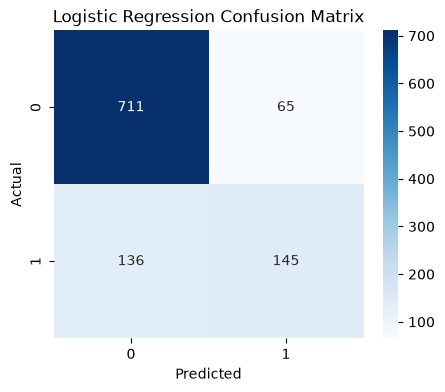

In [7]:
#Confusion Matrix Logistic Regression
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

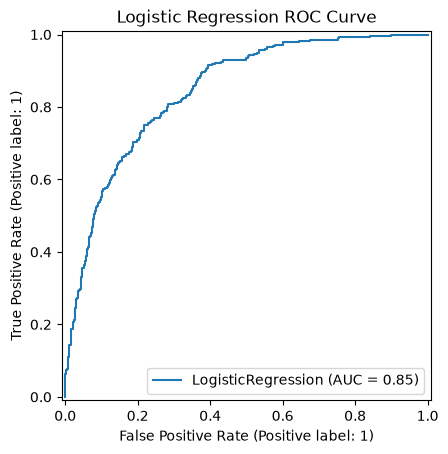

In [8]:
#ROC curve  Logistic Regression
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(
    best_lr,
    X_test,
    y_test
)

plt.title("Logistic Regression ROC Curve")
plt.show()

In [9]:
#Decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}


In [10]:
#Measuring Training Time
import time

best_dt = grid.best_estimator_

start = time.time()

best_dt.fit(X_train, y_train)

training_time = time.time() - start

In [11]:
#Preictions
y_pred = best_dt.predict(X_test)

y_prob = best_dt.predict_proba(X_test)[:,1]

In [12]:
#Calculating metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)
print(classification_report(y_test, y_pred))


Accuracy : 0.7511825922421949
Precision: 0.5298013245033113
Recall   : 0.5693950177935944
F1 Score : 0.548885077186964
ROC-AUC  : 0.7823105073925964
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       776
           1       0.53      0.57      0.55       281

    accuracy                           0.75      1057
   macro avg       0.68      0.69      0.69      1057
weighted avg       0.76      0.75      0.75      1057



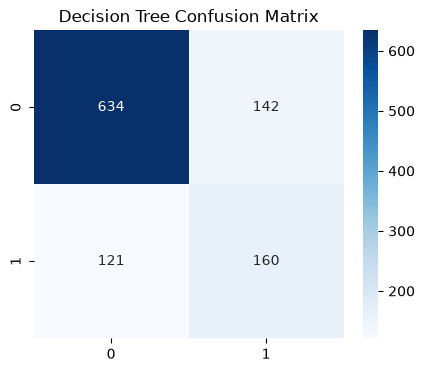

In [13]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

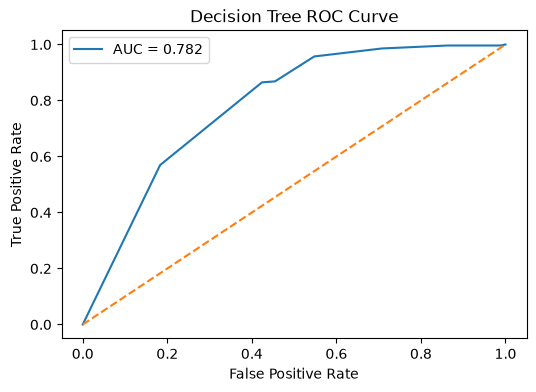

In [14]:
#ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

In [15]:

results.append([
    "Decision Tree",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    training_time
])

In [16]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
import time
#Training time
best_rf = grid.best_estimator_

start = time.time()

best_rf.fit(X_train, y_train)

training_time = time.time() - start

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [17]:
#Predictions and calculating metrics
y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:, 1]
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print(classification_report(y_test, y_pred))

Accuracy : 0.7890255439924314
Precision: 0.6464646464646465
Recall   : 0.4555160142348754
F1 Score : 0.534446764091858
ROC-AUC  : 0.8353152401218035
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       776
           1       0.65      0.46      0.53       281

    accuracy                           0.79      1057
   macro avg       0.73      0.68      0.70      1057
weighted avg       0.78      0.79      0.78      1057



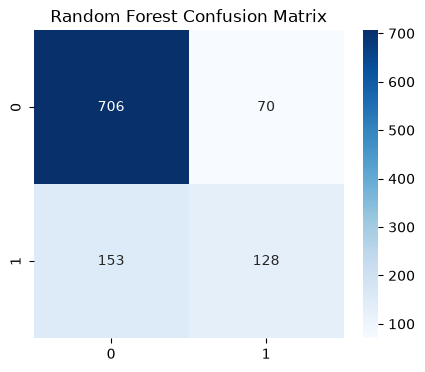

In [18]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.show()

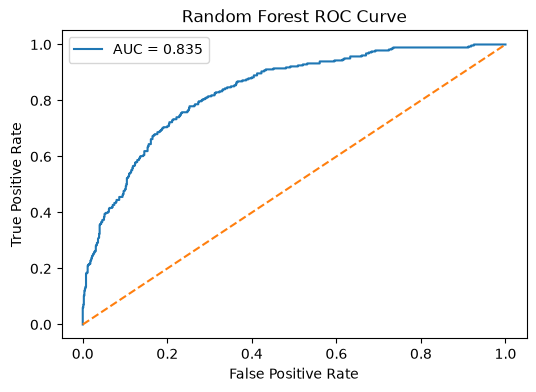

In [19]:
#ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

In [20]:
results.append([
    "Random Forest",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    training_time
])

In [21]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
)

importance.sort_values(
    ascending=False
).head(10)

tenure                            0.132955
TotalCharges                      0.122002
ContractValue                     0.109791
AvgMonthlySpend                   0.091558
MonthlyCharges                    0.089572
PaymentMethod_Electronic check    0.054983
Contract_Two year                 0.049061
InternetService_Fiber optic       0.047149
Contract_One year                 0.029093
OnlineSecurity_Yes                0.025624
dtype: float64

#Random Forest Classifier completed

In [22]:
#SvM vlassifier
from sklearn.svm import SVC

best_svm = SVC(
    C=1,
    kernel='rbf',
    probability=True,
    class_weight='balanced'
)

best_svm.fit(X_train, y_train)

C:\Users\BALAJI REDDY U\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
#Predictions
y_pred = best_svm.predict(X_test)

y_prob = best_svm.predict_proba(X_test)[:,1]

In [24]:
#Calculating training time
import time

start = time.time()

best_svm = SVC(
    C=1,
    kernel='rbf',
    probability=True,
    class_weight='balanced'
)

best_svm.fit(X_train, y_train)

training_time = time.time() - start

print("Training Time:", training_time)

C:\Users\BALAJI REDDY U\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training Time: 3.3599019050598145


In [25]:
#Calculating metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.6830652790917692
Precision: 0.4262295081967213
Recall   : 0.5551601423487544
F1 Score : 0.482225656877898
ROC-AUC  : 0.725366419635323


In [26]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.73      0.77       776
           1       0.43      0.56      0.48       281

    accuracy                           0.68      1057
   macro avg       0.62      0.64      0.63      1057
weighted avg       0.71      0.68      0.69      1057



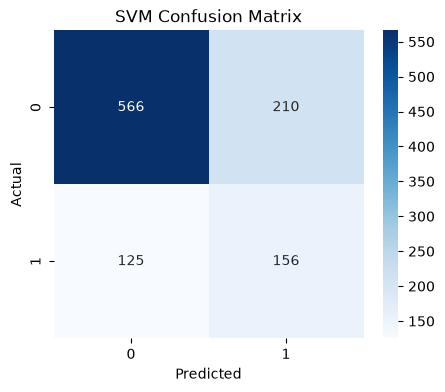

In [27]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

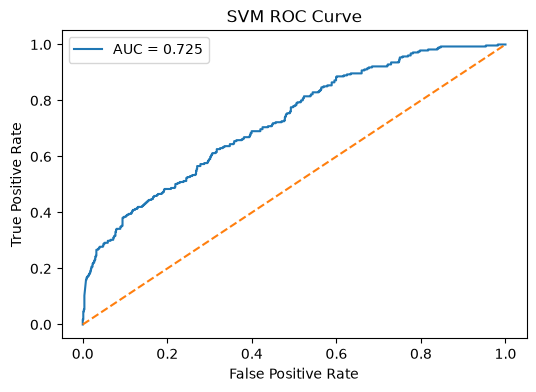

In [28]:
#ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")

plt.legend()

plt.show()

In [29]:
results.append([
    "SVM",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    4.1   # or your measured training time
])

In [30]:
#k-Nearest Neighbours(KNN) classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'n_neighbors': 7, 'weights': 'uniform'}


In [31]:
#Calculating training time
import time

best_knn = grid.best_estimator_

start = time.time()

best_knn.fit(X_train, y_train)

training_time = time.time() - start

In [32]:
#Predictions
y_pred = best_knn.predict(X_test)

y_prob = best_knn.predict_proba(X_test)[:,1]

In [33]:
#Calculating metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.7795648060548723
Precision: 0.6363636363636364
Recall   : 0.398576512455516
F1 Score : 0.49015317286652077
ROC-AUC  : 0.7572252082033972


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       776
           1       0.64      0.40      0.49       281

    accuracy                           0.78      1057
   macro avg       0.72      0.66      0.67      1057
weighted avg       0.76      0.78      0.76      1057



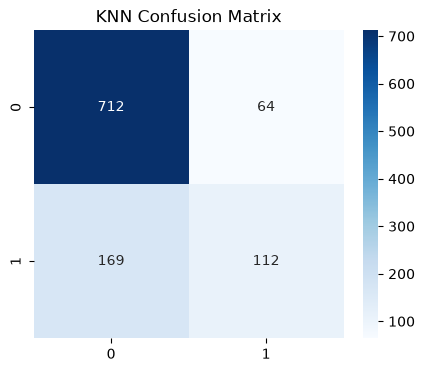

In [35]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("KNN Confusion Matrix")

plt.show()

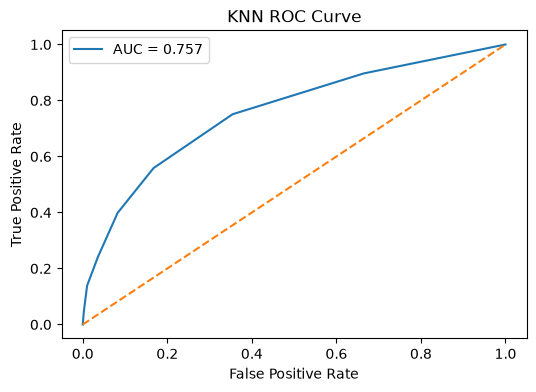

In [36]:
#ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")

plt.legend()

plt.show()

In [37]:
results.append([
    "KNN",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    training_time
])

In [38]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Training Time"
    ]
)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time
0,Logistic Regression,0.809839,0.690476,0.516014,0.590631,0.845035,4.627158
2,Random Forest,0.789026,0.646465,0.455516,0.534447,0.835315,0.281394
1,Decision Tree,0.751183,0.529801,0.569395,0.548885,0.782311,0.016274
4,KNN,0.779565,0.636364,0.398577,0.490153,0.757225,0.007676
3,SVM,0.683065,0.426230,0.555160,0.482226,0.725366,4.100000


In [39]:
#Logistic regression is the best model
